<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula27a_MLP_bin%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

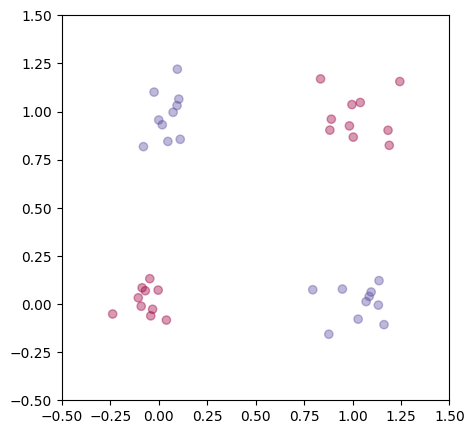

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0,0],[1,0],[1,1],[0,1]],
                    cluster_std=0.1)
  y = np.array([func(a>0.5, b>0.5) for a, b, in zip(X[:,0], X[:,1])], dtype=int) * 2 - 1
  return X, y

X, y = makeLogicalDataset()
plotDataset(X, y)
plt.show()

In [2]:
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


Accuracy: 1.0


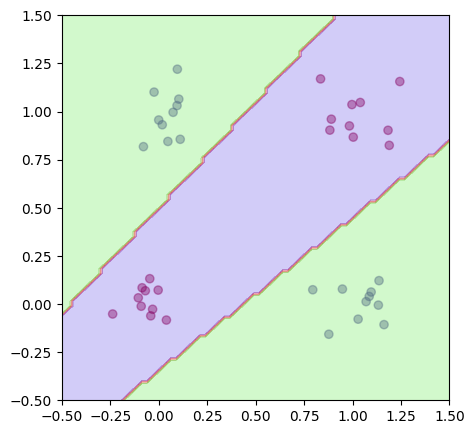

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class SingleHiddenLayer(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=10000, learning_rate=0.01):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.n_hidden = 2

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.ihw = np.random.randn(X.shape[1]+1, self.n_hidden)
        self.how = np.random.randn(self.ihw.shape[1]+1, 1)
        for _ in range(self.max_iter):
            logits = self.forward(X)
            self.backward(y, logits)
        return self

    def backward(self, y, logits):
        ho_delta = y - logits
        ho_grad = self.Hb.T @ ho_delta
        ### ### ### ###
        tanh_grad = (1 - self.H**2)
        ih_delta = ho_delta @ self.how[1:].T * tanh_grad
        ### ### ### ###
        ih_grad = self.Xb.T @ ih_delta
        self.ihw += self.learning_rate * ih_grad
        self.how += self.learning_rate * ho_grad

    def forward(self, X):
        self.Xb = include_bias(X)
        self.pH = self.Xb @ self.ihw
        self.H = np.tanh(self.pH)
        self.Hb = include_bias(self.H)
        logits = self.Hb @ self.how
        return logits

    def predict(self, X):
        logits = self.forward(X)
        return np.sign(logits)

model = SingleHiddenLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


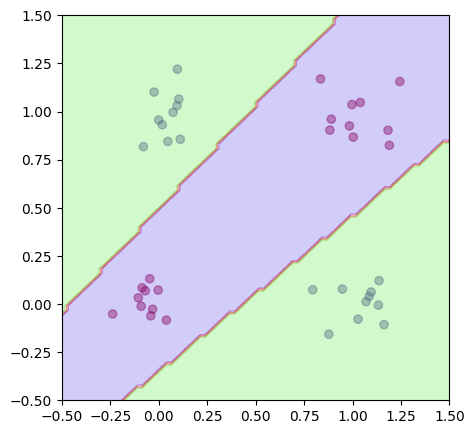

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class MultiLayer(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=10000, learning_rate=0.01, n_hidden=[2]):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.n_hidden = n_hidden

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        self.Ws = []
        previous_output_size = X.shape[1]
        for n in self.n_hidden:
            self.Ws.append(np.random.randn(previous_output_size+1, n))
            previous_output_size = n
        self.Ws.append(np.random.randn(previous_output_size+1, 1))
        for _ in range(self.max_iter):
            logits = self.forward(X)
            self.backward(y, logits)
        return self

    def backward(self, y, logits):
        grads = []
        output_delta = y - logits
        grad = self.A[-1].T @ output_delta
        grads.insert(0, grad)
        for i in range(len(self.Ws)-1, 0, -1):
            tanh_grad = (1 - np.tanh(self.Z[i-1])**2)
            input_delta = output_delta @ self.Ws[i][1:].T * tanh_grad
            grad = self.A[i-1].T @ input_delta
            grads.insert(0, grad)
            output_delta = input_delta
        for i in range(len(self.Ws)):
            self.Ws[i] += self.learning_rate * grads[i]

    def forward(self, X):
        self.A = []
        self.Z = []
        AUX = X.copy()
        for W in self.Ws:
            self.A.append(include_bias(AUX))
            self.Z.append(self.A[-1] @ W)
            AUX = np.tanh(self.Z[-1])
        return AUX

    def predict(self, X):
        logits = self.forward(X)
        return np.sign(logits)

model = MultiLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

In [15]:
X_test, y_test = makeLogicalDataset(n=1000)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 1.0


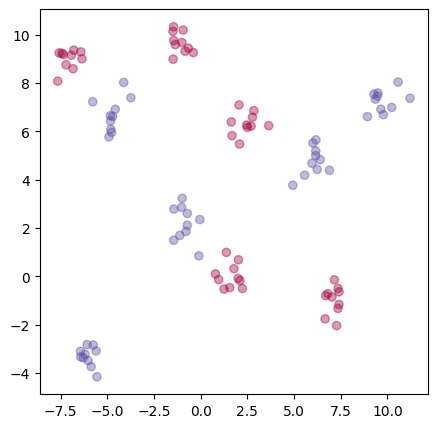

In [19]:
def makeHardDataset(n=100, centers=10, std=0.5):
  X, y = make_blobs(n_samples=n,
                    centers=centers,
                    cluster_std=std)
  y = np.where(y%2==0, 1, -1)
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)

X, y = makeHardDataset()
plotDataset(X, y)
plt.show()

Accuracy: 1.0


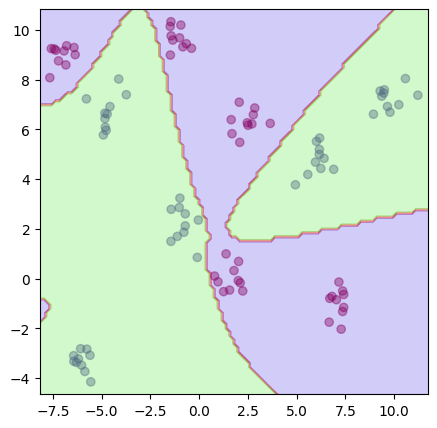

In [32]:
model = MultiLayer(20000, 0.001, n_hidden=[10, 10])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


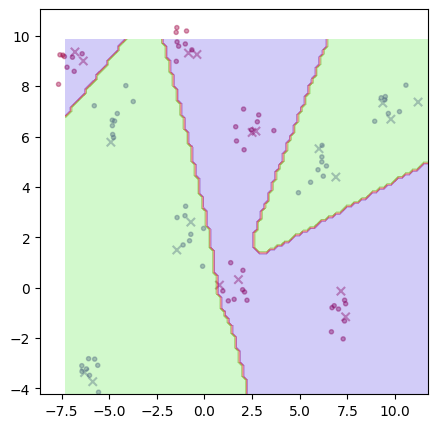

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, marker='.', alpha=0.4, cmap=plt.cm.Spectral)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker='x', alpha=0.4, cmap=plt.cm.Spectral)
plotPredictions(model, X_test)
plt.show()